In [1]:
# ============================================
# TASK 2: DEEP LEARNING MODEL
# ============================================

# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
# Load dataset

data = load_breast_cancer()

# Convert dataset into DataFrame

df = pd.DataFrame(
    data.data,
    columns=data.feature_names
)

# Add target column

df['target'] = data.target

print("Dataset Loaded Successfully!\n")

# Print first 5 rows

print("First 5 Rows of Dataset:\n")

print(df.head())

# Print complete dataset

print("\nComplete Dataset:\n")

print(df)

# Print dataset shape

print("\nDataset Shape:", df.shape)

Dataset Loaded Successfully!

First 5 Rows of Dataset:

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  wors

In [3]:
# Separate features and target

X = df.drop('target', axis=1)

y = df['target']

print("Features:\n")
print(X.head())

print("\nTarget:\n")
print(y.head())

Features:

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0

In [4]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("\nTraining Data Preview:\n")
print(X_train.head())

Training Features Shape: (455, 30)
Testing Features Shape: (114, 30)

Training Data Preview:

     mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
68         9.029         17.33           58.79      250.5          0.10660   
181       21.090         26.57          142.70     1311.0          0.11410   
63         9.173         13.86           59.20      260.9          0.07721   
248       10.650         25.22           68.01      347.0          0.09657   
60        10.170         14.88           64.55      311.9          0.11340   

     mean compactness  mean concavity  mean concave points  mean symmetry  \
68            0.14130         0.31300              0.04375         0.2111   
181           0.28320         0.24870              0.14960         0.2395   
63            0.08751         0.05988              0.02180         0.2341   
248           0.07234         0.02379              0.01615         0.1897   
60            0.08061         0.01084              0

In [5]:
# Apply feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Convert scaled data to DataFrame

X_train_scaled_df = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

print("Scaled Training Data:\n")

print(X_train_scaled_df.head())

Scaled Training Data:

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0    -1.440753     -0.435319       -1.362085  -1.139118         0.780573   
1     1.974096      1.733026        2.091672   1.851973         1.319843   
2    -1.399982     -1.249622       -1.345209  -1.109785        -1.332645   
3    -0.981797      1.416222       -0.982587  -0.866944         0.059390   
4    -1.117700     -1.010259       -1.125002  -0.965942         1.269511   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          0.718921        2.823135            -0.119150       1.092662   
1          3.426275        2.013112             2.665032       2.127004   
2         -0.307355       -0.365558            -0.696502       1.930333   
3         -0.596788       -0.820203            -0.845115       0.313264   
4         -0.439002       -0.983341            -0.930600       3.394436   

   mean fractal dimension  ...  worst radius  worst texture  worst pe

In [6]:
# ============================================
# BUILD DEEP LEARNING MODEL
# ============================================

model = Sequential()

# Input + Hidden Layer 1

model.add(Dense(
    16,
    activation='relu',
    input_shape=(X_train_scaled.shape[1],)
))

# Hidden Layer 2

model.add(Dense(
    8,
    activation='relu'
))

# Output Layer

model.add(Dense(
    1,
    activation='sigmoid'
))

print("Neural Network Model Built Successfully!")

C:\Users\jayal\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Neural Network Model Built Successfully!


In [7]:
# Display model summary

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16)                  │             496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 641 (2.50 KB)

 Trainable params: 641 (2.50 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# Compile model

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully!")

Model Compiled Successfully!


In [9]:
# Train model

history = model.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    validation_data=(X_test_scaled, y_test)
)

print("Model Training Completed!")

Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.7341 - loss: 0.5985 - val_accuracy: 0.7895 - val_loss: 0.5311
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8374 - loss: 0.4889 - val_accuracy: 0.8509 - val_loss: 0.4368
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8637 - loss: 0.4025 - val_accuracy: 0.9035 - val_loss: 0.3568
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8879 - loss: 0.3353 - val_accuracy: 0.9386 - val_loss: 0.2933
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9077 - loss: 0.2859 - val_accuracy: 0.9474 - val_loss: 0.2451
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9143 - loss: 0.2489 - val_accuracy: 0.9561 - val_loss: 0.2082
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9187 - loss: 0.2208 - val_accuracy: 0.9474 - val_loss: 0.1805
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9275 - loss: 0.1990 - val_accuracy: 0.9561 - v

In [10]:
# Evaluate model

loss, accuracy = model.evaluate(
    X_test_scaled,
    y_test
)

print("\nModel Loss:", loss)

print("Model Accuracy:", accuracy)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9737 - loss: 0.0721

Model Loss: 0.07209155708551407
Model Accuracy: 0.9736841917037964


In [11]:
# Predict values

predictions = model.predict(X_test_scaled)

print("Predictions:\n")

print(predictions[:10])

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predictions:

[[8.8008356e-01]
 [1.1569908e-03]
 [2.2051994e-02]
 [9.7866613e-01]
 [9.9239391e-01]
 [2.3072664e-07]
 [5.1817810e-06]
 [7.5646609e-02]
 [7.0101649e-01]
 [9.9652344e-01]]


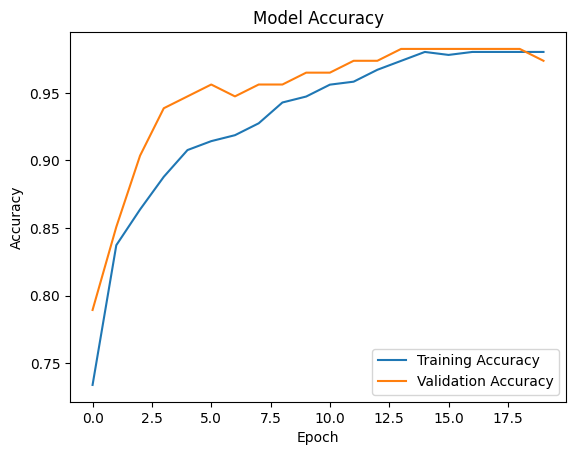

In [12]:
# Plot accuracy graph

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.show()

In [13]:
# Save trained model

model.save('deep_learning_model.h5')

print("Model Saved Successfully!")

Model Saved Successfully!


In [14]:
# Save graph image

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.xlabel('Epoch')

plt.ylabel('Accuracy')

plt.legend([
    'Training Accuracy',
    'Validation Accuracy'
])

plt.savefig('accuracy_graph.png')

plt.close()

print("Accuracy Graph Saved Successfully!")

Accuracy Graph Saved Successfully!
